This is the initial simulation, \vers{I} is assumed to be in the x-y plane for dim=2 and x-z for dim=3.
In this plane [0,-1,0] is the psi=0 direction.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# import numba as nb

In [2]:
# System parameters

dim = 2

D_n = 0.067 #0.1 #0.5
D_r = 0.
V0 = 1.
w_0 = 1. #10.

vec_I = np.zeros(dim)
vec_I[-1] = -1

In [3]:
# Simulation parameters

N_samples = 10**3
nt = 2000 #800    # number of times steps

dt = 5*10**-2
if not dt < 0.01 / D_n:
    raise Exception("too large time step")

In [4]:
r0 = np.zeros((dim, N_samples))

n0 = np.zeros((dim,N_samples))
n0[0,:] = 1 # n0[-1,:] = 1


r = np.copy(r0) # initial position
n = np.copy(n0) # initial orientation

In [5]:
# Tensor for saving positions
r_history = np.zeros((nt+1, dim, N_samples))
r_history[0,:,:] = r0

n_history = np.zeros((nt+1, dim, N_samples))
n_history[0,:,:] = n0

In [6]:
def I(r):   # (dim, sample)
    return 1

def f(x):
    return w_0*0.3*np.sin(x)  # f2-f1 #TODO implement better approximation or original functions

def Omega(I,psi):  # we later take x = I(r)*sin(psi)
    x=I*np.sin(psi)
    return f(x)


zeta_n = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))
zeta_r = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))

dn_rand = np.sqrt(2*D_n*dt)*zeta_n
dr_rand = np.sqrt(2*D_r*dt)*zeta_r

In [7]:
# Time evolution

for it in range(nt):
    dot_prod = np.sum(-vec_I[:, None] * n, axis=0) # (N_samples,)
    psi = np.arccos(dot_prod) # (N_samples,), I(r) has shape (N_samples,) too
    dn_rot = dt*Omega(I(r), psi)*(-dot_prod*n -vec_I[:,None])

    dn = dn_rand[it,:,:] # noise term
    dn -= n*np.sum(n*dn, axis=0) # project onto tangent space


    n += dn + dn_rot
    n /= np.linalg.norm(n, axis=0)
    
    r = n*V0*dt + r + dr_rand[it,:]
    r_history[it+1,:,:] = r
    n_history[it+1,:,:] = n

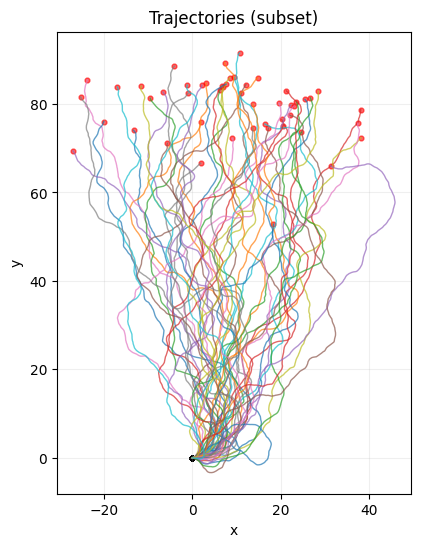

In [8]:
# Visualize trajectories in r_history
# r_history shape: (nt+1, dim, N_samples)

n_show = min(50, N_samples)           # number of trajectories to plot
idx = np.linspace(0, N_samples - 1, n_show, dtype=int)

t = np.arange(r_history.shape[0])

if dim == 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Trajectories (subset)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    plt.show()

elif dim == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], r_history[:, 2, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], r_history[0, 2, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], r_history[-1, 2, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Trajectories (subset)")
    plt.show()

## Metrics 


Mean angles over time

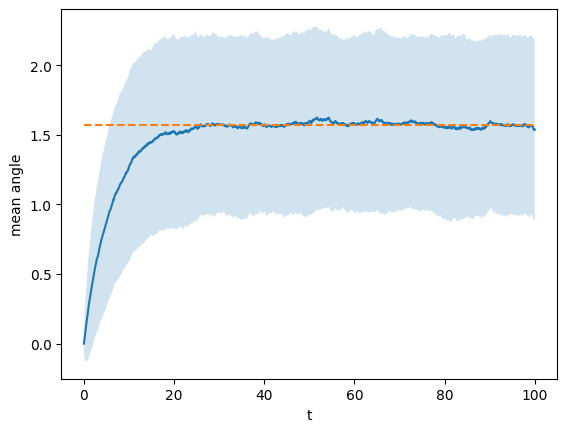

In [19]:
y = n_history[:,-1,:] # shape (Nt, dim, N_samples)
x = n_history[:,0,:]
angle_xy = np.atan2(y,x)




angles = angle_xy  # shape (Nt, N_samples)

# complex average
z = np.exp(1j * angle_xy)
mean_z = np.mean(z, axis=1)

# circular mean
mean_angle = np.angle(mean_z)

# circular std
R = np.abs(mean_z)              # mean resultant length
std_angle = np.sqrt(-2*np.log(R))



t_steps = dt*np.arange(0,nt+1)

plt.fill_between(
    t_steps,
    mean_angle - std_angle,
    mean_angle + std_angle,
    alpha=0.2
)

plt.plot(t_steps, mean_angle)
plt.plot(t_steps, np.pi/2*np.ones_like(t_steps), '--')
plt.xlabel("t")
plt.ylabel("mean angle")
plt.show()

Histogram of initial angles

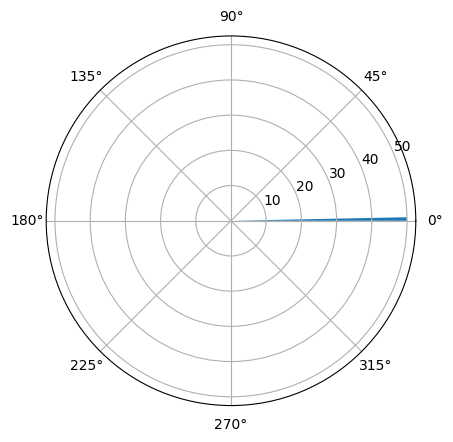

In [10]:
# Histogram of final angles

y = n0[-1,:]   # for dim == 3 technically its z
x = n0[0,:]
angle_xy = np.atan2(y,x)

# plt.hist(angle_xy, bins=50, range=(-np.pi, np.pi), density=True)
# plt.xlabel("angle")
# plt.ylabel("PDF")
# plt.show()

ax = plt.subplot(projection='polar')
ax.hist(angle_xy, bins=50, density=True)
plt.show()

Histogram of final angles

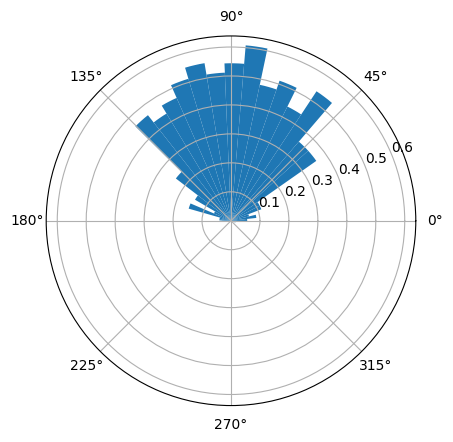

In [11]:
# Histogram of final angles

y = n[-1,:]   # for dim == 3 technically its z
x = n[0,:]
angle_xy = np.atan2(y,x)

# plt.hist(angle_xy, bins=50, range=(-np.pi, np.pi), density=True)
# plt.xlabel("angle")
# plt.ylabel("PDF")
# plt.show()

ax = plt.subplot(projection='polar')
ax.hist(angle_xy, bins=50, density=True)
plt.show()

10 iteration intervals

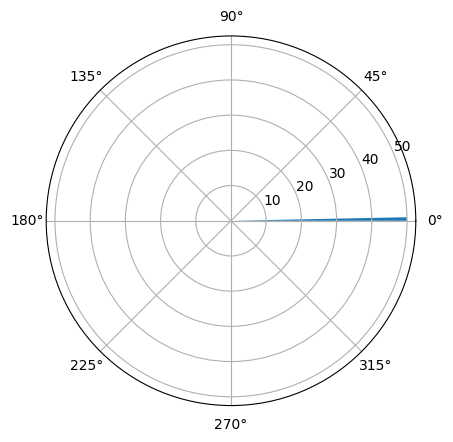

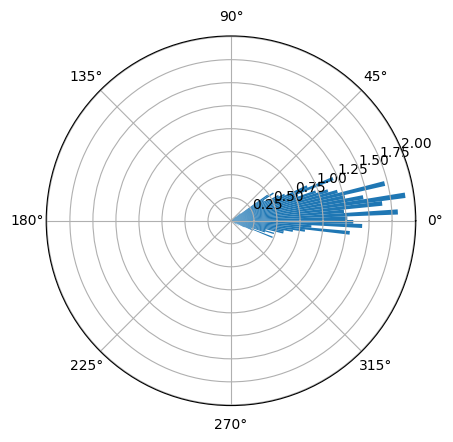

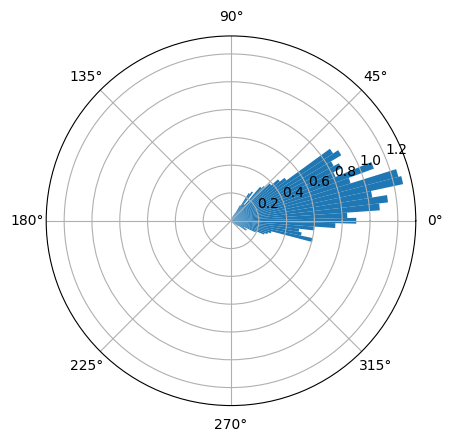

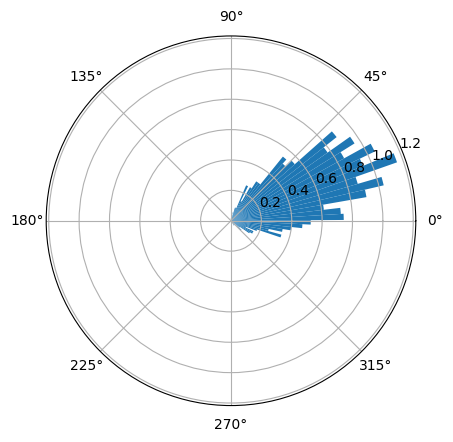

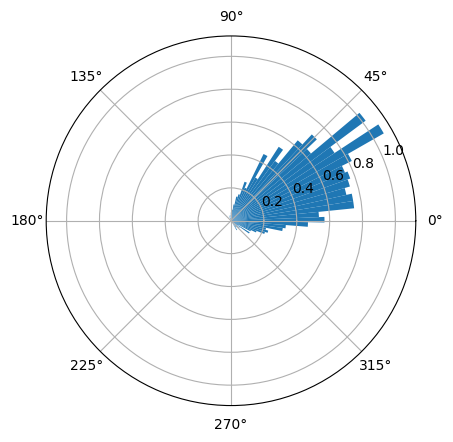

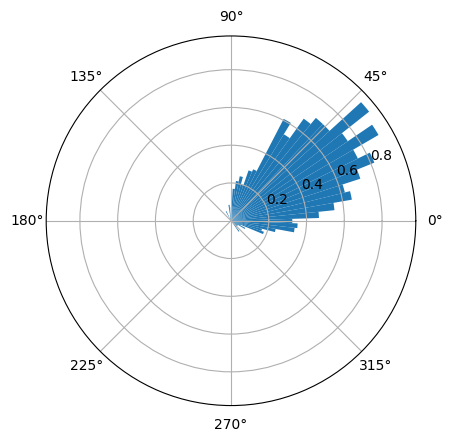

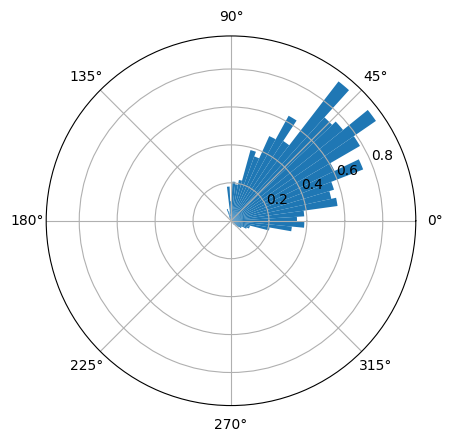

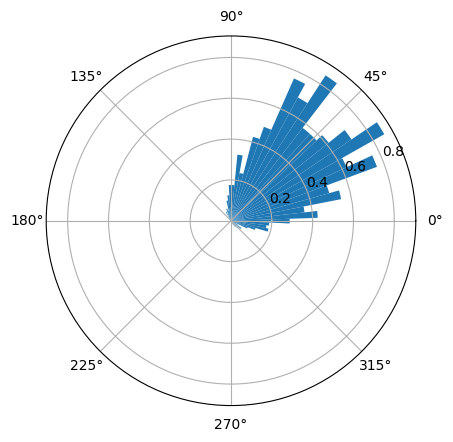

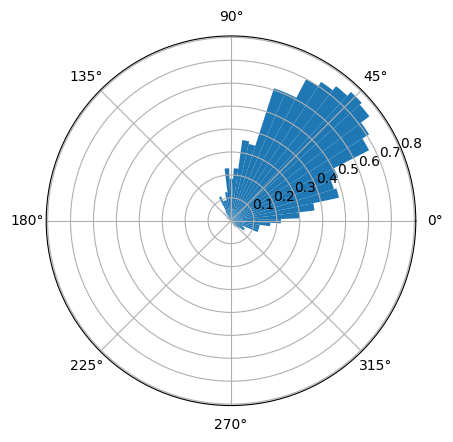

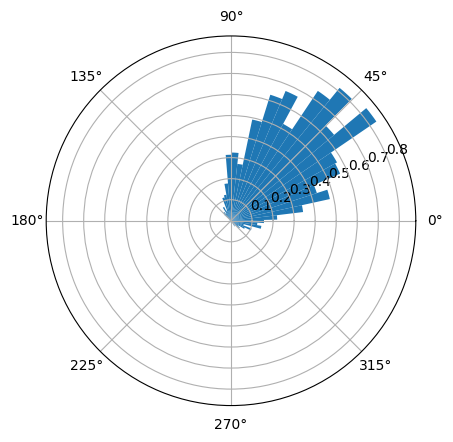

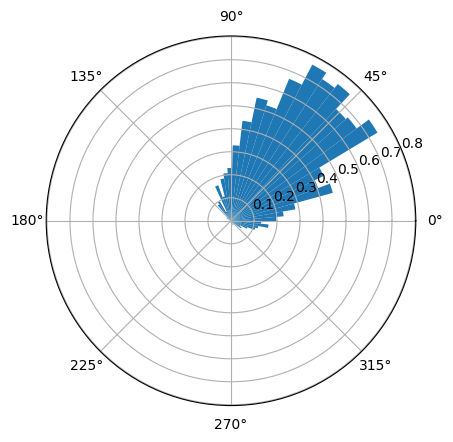

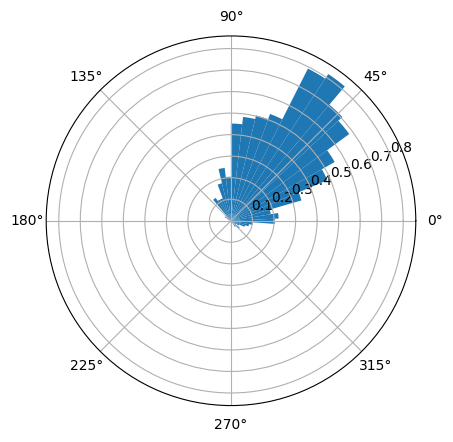

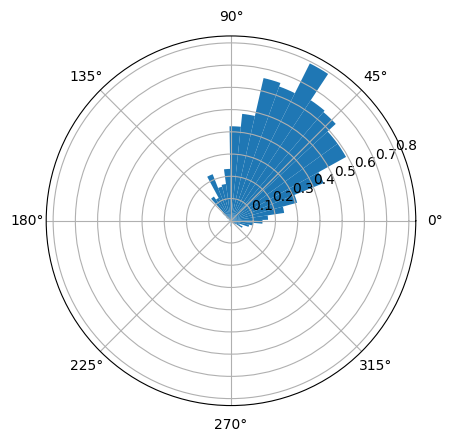

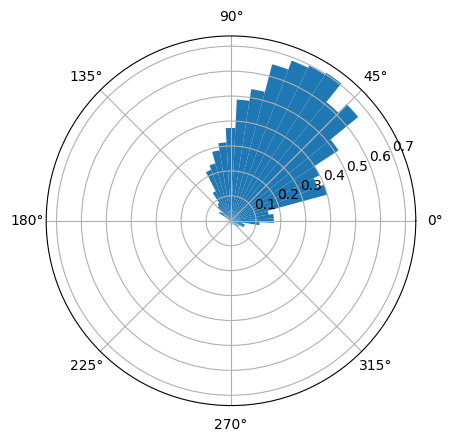

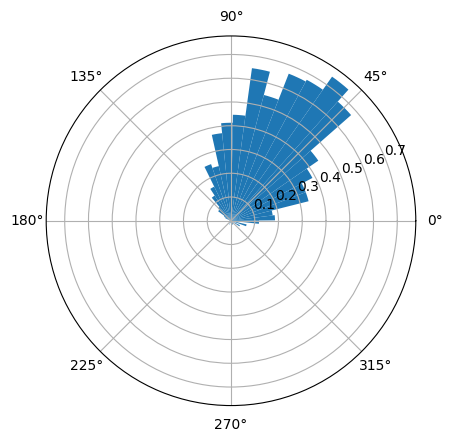

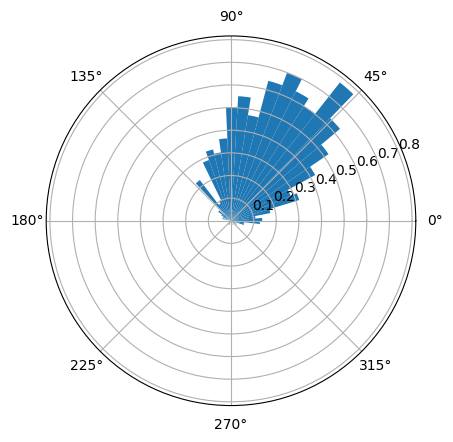

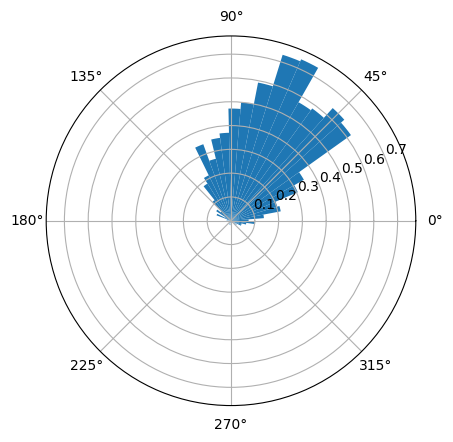

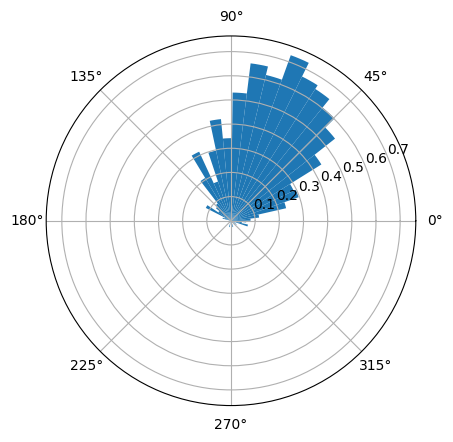

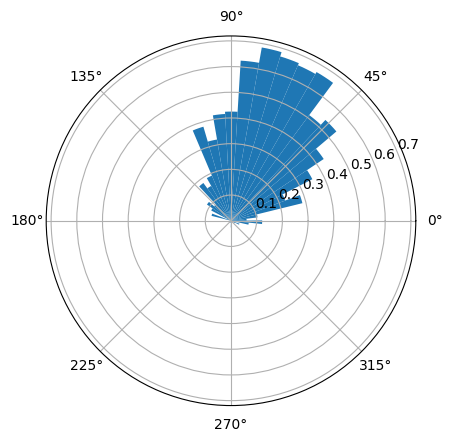

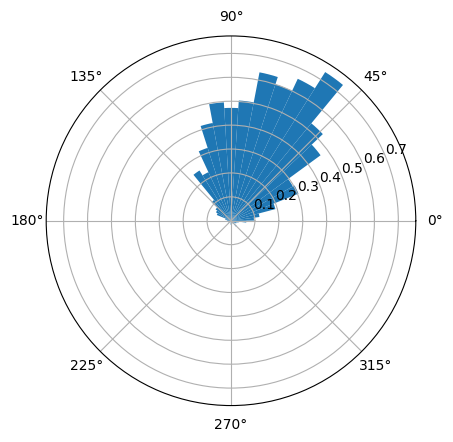

In [12]:
for it in range(20):

    y = n_history[10*it,-1,:]
    x = n_history[10*it,0,:]
    angle_xy = np.atan2(y,x)

    # print(it)
    # plt.hist(angle_xy, bins=50, range=(-np.pi, np.pi), density=False)
    # plt.xlabel("angle")
    # plt.ylabel("PDF")
    # plt.show()

    ax = plt.subplot(projection='polar')
    ax.hist(angle_xy, bins=50, density=True)
    plt.show()

0


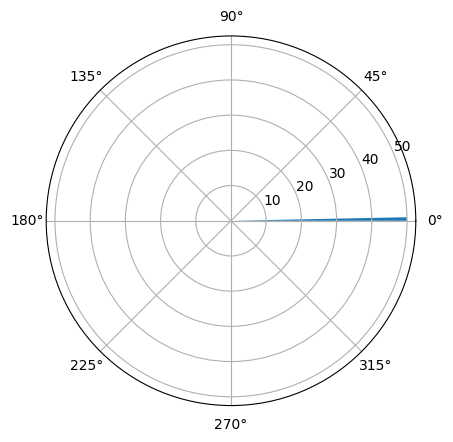

400


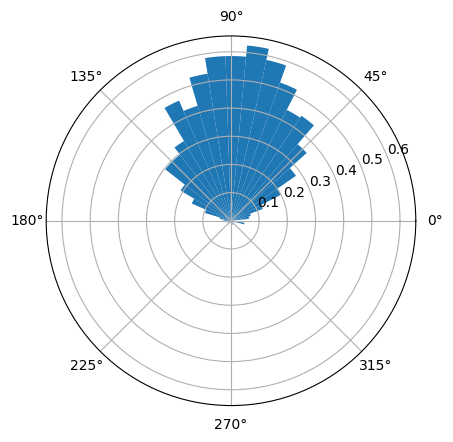

800


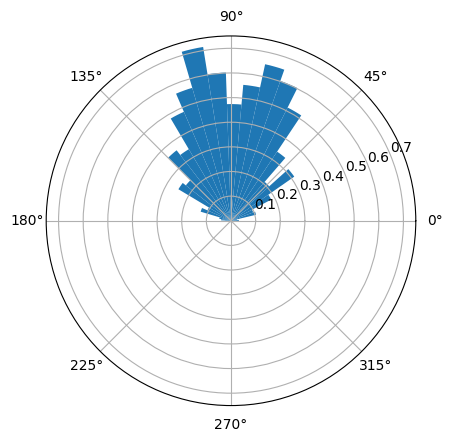

1200


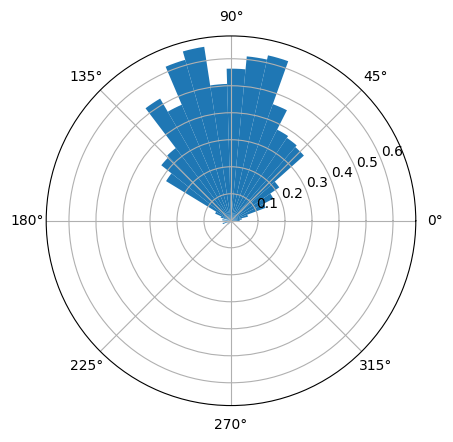

1600


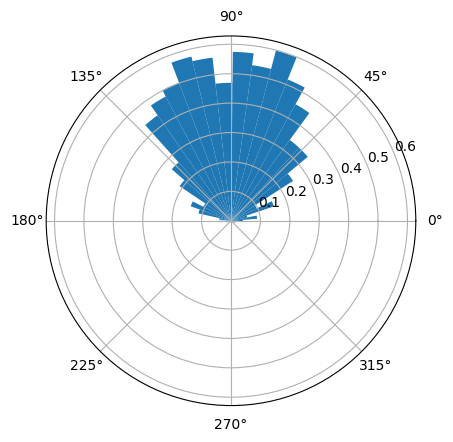

2000


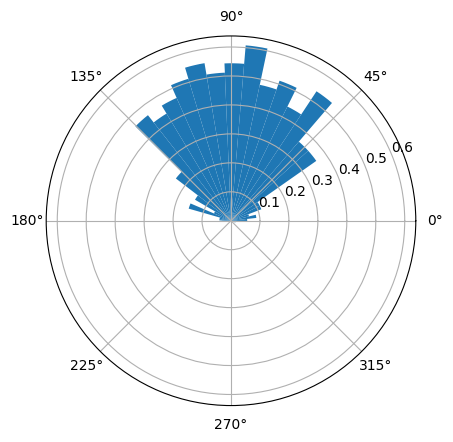

In [13]:
for it in range(5+1):
    idx = (it)*nt//5
    y = n_history[idx,-1,:]
    x = n_history[idx,0,:]
    angle_xy = np.atan2(y,x)

    print(idx)

    # plt.hist(angle_xy, bins=50, range=(-np.pi, np.pi), density=False)
    # plt.xlabel("angle")
    # plt.ylabel("PDF")
    # plt.show()

    ax = plt.subplot(projection='polar')
    ax.hist(angle_xy, bins=50, density=True)
    plt.show()